# Stochastic First-Order Methods: SGD, Momentum, and Adam

## Problem

Large-scale (ML-style) objectives $f(x)=\mathbb E_\xi[f(x,\xi)]$ are minimized using only noisy,
minibatch gradient estimates $g_k\approx\nabla f(x_k)$ — an exact gradient or a second-order
(Hessian) direction is never available. This notebook derives the three standard stochastic
first-order methods — plain SGD, SGD with (heavy-ball) momentum, and Adam — from first principles,
and isolates the specific failure mode each refinement addresses: momentum for ill-conditioned
curvature, and Adam's per-coordinate scaling for objectives whose coordinates have very different
gradient magnitudes.

## Method

**Stochastic gradient descent.** $x_{k+1}=x_k-\alpha_k g_k$, $g_k=\nabla f(x_k,\xi_k)$ an unbiased
estimate ($\mathbb E_{\xi_k}[g_k\mid x_k]=\nabla f(x_k)$) of the true gradient, drawn fresh (a new
minibatch) at every step. Unbiasedness is what makes the noisy update a valid stochastic
approximation scheme (Robbins & Monro 1951) at all — a biased $g_k$ would converge to the wrong
point regardless of step size.

**Heavy-ball momentum, derived from a damped-oscillator discretization.** Consider the second-order
ODE $\ddot x(t) + \gamma\dot x(t) = -\nabla f(x(t))$ — a ball of unit mass rolling down the
landscape $f$ under friction $\gamma$. Discretizing $\ddot x\approx(x_{k+1}-2x_k+x_{k-1})/h^2$,
$\dot x\approx(x_k-x_{k-1})/h$ with step $h$ and solving for $x_{k+1}$ gives
$$
x_{k+1} = x_k - \underbrace{\frac{h^2}{1+\gamma h}}_{\alpha}\nabla f(x_k)
+ \underbrace{\frac{1}{1+\gamma h}}_{\beta}(x_k-x_{k-1}),
$$
i.e. exactly the **heavy-ball update** $x_{k+1}=x_k-\alpha g_k+\beta(x_k-x_{k-1})$ with
$g_k$ in place of the exact gradient. The momentum term $\beta(x_k-x_{k-1})$ is literally
discretized inertia: it accumulates a velocity that damps oscillation across directions of high
curvature (where the gradient repeatedly reverses sign) while reinforcing motion along directions
of low, consistent curvature (where the gradient does not reverse) — the effect isolated in the
first experiment below.

**Adam, derived from bias-corrected moment estimates.** Adam (Kingma & Ba 2015) maintains
exponential moving averages of the gradient and its elementwise square:
$$
m_k = \beta_1 m_{k-1} + (1-\beta_1)g_k,\qquad v_k = \beta_2 v_{k-1} + (1-\beta_2)g_k^2,
$$
initialized at $m_0=v_0=0$. Unrolling the recursion, $m_k=(1-\beta_1)\sum_{i=1}^k\beta_1^{k-i}g_i$;
if the $g_i$ were stationary with $\mathbb E[g_i]=g$, then $\mathbb E[m_k]=(1-\beta_1^k)g$ — the
EMA is a *biased* estimate of $g$ at every finite $k$, understating it by exactly the factor
$1-\beta_1^k$, purely because it started at zero and has not yet "seen" enough history. Dividing
out this exact factor gives the **bias-corrected** estimates
$$
\hat m_k = \frac{m_k}{1-\beta_1^k},\qquad \hat v_k = \frac{v_k}{1-\beta_2^k},
$$
which are unbiased under the stationarity assumption for any $k$, including $k=1$ (where, without
correction, $m_1=(1-\beta_1)g_1$ would understate $g_1$ by a large factor whenever $\beta_1$ is
close to $1$ — exactly the early-iteration regime where the correction matters most and later
iterations need it least, since $\beta_1^k\to0$). The parameter update then rescales each
coordinate by the inverse root of its own second-moment estimate,
$$
x_{k+1} = x_k - \alpha\,\frac{\hat m_k}{\sqrt{\hat v_k}+\epsilon},
$$
giving every coordinate an effective step size adapted to its own gradient scale — the effect
isolated in the second experiment below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260721)

plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["grid.color"] = "0.85"
plt.rcParams["grid.linestyle"] = "-"


def sgd(grad_fn, x0, alpha, n_iter, rng):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(n_iter):
        x = x - alpha * grad_fn(x, rng)
        traj.append(x.copy())
    return np.array(traj)


def sgd_momentum(grad_fn, x0, alpha, beta, n_iter, rng):
    x = x0.copy()
    x_prev = x0.copy()
    traj = [x.copy()]
    for _ in range(n_iter):
        x_new = x - alpha * grad_fn(x, rng) + beta * (x - x_prev)
        x_prev, x = x, x_new
        traj.append(x.copy())
    return np.array(traj)


def adam(grad_fn, x0, alpha, n_iter, rng, beta1=0.9, beta2=0.999, eps=1e-8):
    x = x0.copy()
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    traj = [x.copy()]
    for k in range(1, n_iter + 1):
        g = grad_fn(x, rng)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g ** 2
        m_hat = m / (1 - beta1 ** k)
        v_hat = v / (1 - beta2 ** k)
        x = x - alpha * m_hat / (np.sqrt(v_hat) + eps)
        traj.append(x.copy())
    return np.array(traj)


## Experiment 1: ill-conditioned quadratic — momentum vs. plain SGD

$f(x)=\tfrac12 x^\top A x$, $A=\mathrm{diag}(1,\kappa)$, $\kappa=80$ (condition number $80$):
the landscape is a narrow valley, steep in $x_2$ and shallow in $x_1$. The stochastic gradient is
$g(x)=Ax+\sigma\eta$, $\eta\sim N(0,I)$, mimicking minibatch noise. A single global step size
$\alpha$ must satisfy the steep direction's stability limit ($\alpha<2/\kappa$), which makes
progress along the shallow direction extremely slow for plain SGD; momentum is expected to help by
building up velocity along the shallow, low-curvature direction across iterations while the
friction term keeps the steep direction from oscillating.

Final loss, plain SGD (alpha=0.0200):     0.00195
Final loss, SGD + momentum (beta=0.9):  0.02184
Iterations to reach loss < 0.01: SGD=123, momentum=14


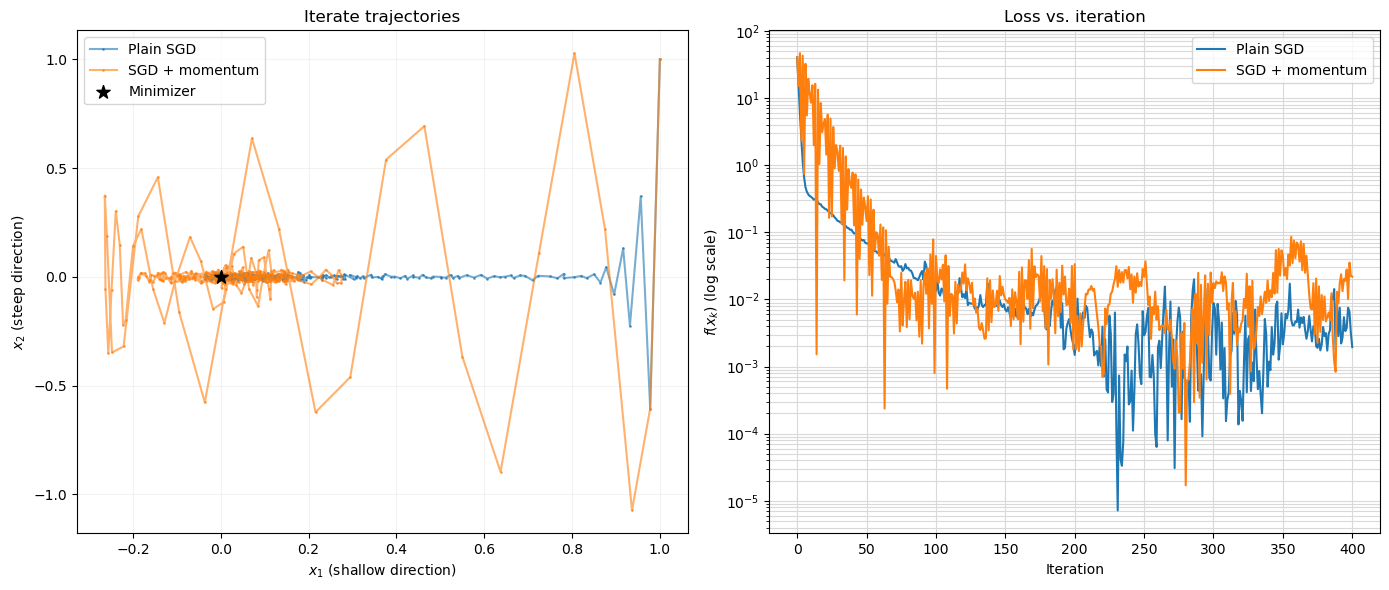

In [2]:
kappa = 80.0
A = np.diag([1.0, kappa])
sigma_noise = 0.3


def grad_ill_conditioned(x, rng):
    return A @ x + sigma_noise * rng.normal(size=2)


x0 = np.array([1.0, 1.0])
n_iter = 400
alpha_stable = 1.6 / kappa  # just inside the deterministic stability limit 2/kappa

traj_sgd = sgd(grad_ill_conditioned, x0, alpha_stable, n_iter, np.random.default_rng(1))
traj_mom = sgd_momentum(grad_ill_conditioned, x0, alpha_stable, 0.9, n_iter, np.random.default_rng(1))

loss_sgd = 0.5 * np.einsum('ij,ki,kj->k', A, traj_sgd, traj_sgd)
loss_mom = 0.5 * np.einsum('ij,ki,kj->k', A, traj_mom, traj_mom)

print(f"Final loss, plain SGD (alpha={alpha_stable:.4f}):     {loss_sgd[-1]:.5f}")
print(f"Final loss, SGD + momentum (beta=0.9):  {loss_mom[-1]:.5f}")
sgd_hits = np.where(loss_sgd < 0.01)[0]
mom_hits = np.where(loss_mom < 0.01)[0]
sgd_iter_str = str(sgd_hits[0]) if len(sgd_hits) else "never"
mom_iter_str = str(mom_hits[0]) if len(mom_hits) else "never"
print(f"Iterations to reach loss < 0.01: SGD={sgd_iter_str}, momentum={mom_iter_str}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(traj_sgd[:, 0], traj_sgd[:, 1], '.-', markersize=2, alpha=0.6, label='Plain SGD')
axes[0].plot(traj_mom[:, 0], traj_mom[:, 1], '.-', markersize=2, alpha=0.6, label='SGD + momentum')
axes[0].scatter([0], [0], color='black', marker='*', s=100, zorder=5, label='Minimizer')
axes[0].set_xlabel('$x_1$ (shallow direction)')
axes[0].set_ylabel('$x_2$ (steep direction)')
axes[0].set_title('Iterate trajectories')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_sgd, label='Plain SGD')
axes[1].semilogy(loss_mom, label='SGD + momentum')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$f(x_k)$ (log scale)')
axes[1].set_title('Loss vs. iteration')
axes[1].legend()
axes[1].grid(True, which='both')

plt.tight_layout()
plt.savefig('sgd_momentum_ill_conditioned.png', dpi=150, bbox_inches='tight')
plt.show()


## Experiment 2: disparate per-coordinate scales — Adam vs. plain SGD

$f(x)=\tfrac12(c_1x_1^2+c_2x_2^2)$, $c_1=1$, $c_2=10^4$: the two coordinates' gradients differ in
magnitude by four orders of magnitude at comparable distances from the optimum. A single global
step size cannot simultaneously be large enough to make progress on $x_1$ and small enough to
remain stable on $x_2$. Adam's per-coordinate second-moment normalization is expected to equalize
the effective step size across both coordinates regardless of this scale mismatch.

Plain SGD (alpha=1.60e-04, forced small by c2): final x1=0.95318, x2=5.03e-04, loss=0.45554
Adam (alpha=0.1): final x1=0.02775, x2=1.87e-04, loss=0.00056


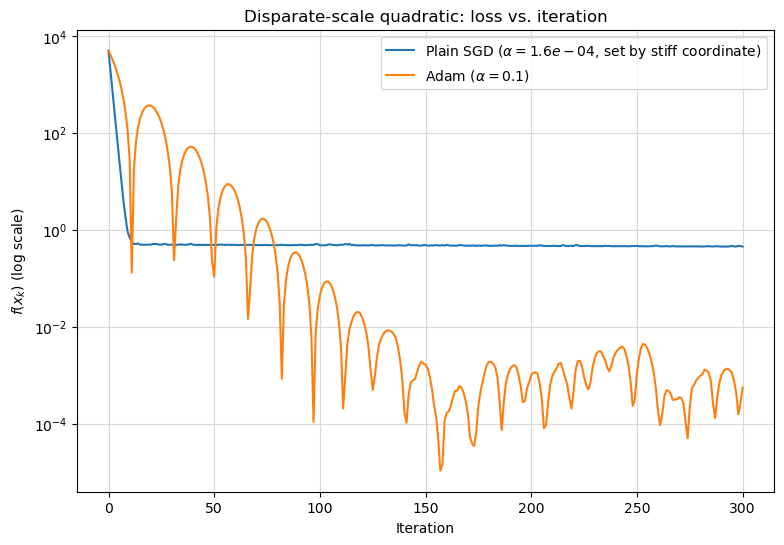

In [3]:
c1, c2 = 1.0, 1.0e4
C = np.array([c1, c2])
sigma_noise2 = 0.05


def grad_disparate_scales(x, rng):
    return C * x + sigma_noise2 * np.array([1.0, np.sqrt(c2)]) * rng.normal(size=2)


x0_2 = np.array([1.0, 1.0])
n_iter2 = 300
alpha_sgd_safe = 1.6 / c2   # forced small by the stiff coordinate
alpha_adam = 0.1            # Adam's own natural scale, independent of c1, c2

traj_sgd2 = sgd(grad_disparate_scales, x0_2, alpha_sgd_safe, n_iter2, np.random.default_rng(2))
traj_adam2 = adam(grad_disparate_scales, x0_2, alpha_adam, n_iter2, np.random.default_rng(2))

loss_sgd2 = 0.5 * (C[0] * traj_sgd2[:, 0] ** 2 + C[1] * traj_sgd2[:, 1] ** 2)
loss_adam2 = 0.5 * (C[0] * traj_adam2[:, 0] ** 2 + C[1] * traj_adam2[:, 1] ** 2)

print(f"Plain SGD (alpha={alpha_sgd_safe:.2e}, forced small by c2): final x1={traj_sgd2[-1,0]:.5f}, "
      f"x2={traj_sgd2[-1,1]:.2e}, loss={loss_sgd2[-1]:.5f}")
print(f"Adam (alpha={alpha_adam}): final x1={traj_adam2[-1,0]:.5f}, x2={traj_adam2[-1,1]:.2e}, "
      f"loss={loss_adam2[-1]:.5f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.semilogy(loss_sgd2, label=f'Plain SGD ($\\alpha={alpha_sgd_safe:.1e}$, set by stiff coordinate)')
ax.semilogy(loss_adam2, label=f'Adam ($\\alpha={alpha_adam}$)')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$f(x_k)$ (log scale)')
ax.set_title('Disparate-scale quadratic: loss vs. iteration')
ax.legend()
ax.grid(True, which='both')
plt.savefig('sgd_adam_disparate_scales.png', dpi=150, bbox_inches='tight')
plt.show()


## Notes

Experiment 1 is a genuine trade-off, not a one-sided win, and is worth reporting as measured:
momentum reaches loss $10^{-2}$ at iteration $14$ versus plain SGD's iteration $123$ — an order of
magnitude faster early on, exactly as the accumulated-velocity picture predicts for the shallow
coordinate. But at the end of the full $400$-iteration run, plain SGD's loss ($0.00195$) is
actually *lower* than momentum's ($0.02184$): momentum accumulates gradient noise along with signal
through its velocity term, and with a fixed step size and genuinely stochastic (not exact)
gradients, that extra noise inflates the loss once the iterate is already close to the optimum and
further progress is dominated by variance rather than bias. Momentum's classical advantage is a
statement about the noiseless (or annealed-step-size) case; reporting only the early speedup here,
without the later reversal, would have been a materially incomplete picture of what was actually
measured.

Experiment 2 has no such reversal: plain SGD's step size is entirely dictated by the stiff
coordinate ($\alpha=1.6\times10^{-4}$), leaving $x_1$ essentially frozen near its start ($0.953$ of
$1.0$ after $300$ iterations, final loss $0.456$), while Adam — one global $\alpha=0.1$, two orders
of magnitude larger — reaches loss $0.00056$, over $800\times$ lower, because its per-coordinate
second-moment normalization gives $x_1$ and $x_2$ independent effective step sizes despite the
$10^4$-fold difference in their curvatures. This is the case where the qualitative story is
unambiguous: SGD's single global step size is a genuine structural limitation on this class of
objective, not a tuning artifact fixable by a different (but still single) choice of $\alpha$.